In [ ]:
# Important Imports, System Parameters and Drive Parameters:
import dynamiqs as dq
import jax.numpy as jnp
from pathlib import Path
import json
import matplotlib.pyplot as plt 

# System Parameters:
params = {
    "Xcc" : 160.0, 
    "Kappa_c" : 0.0207   
}

# Drive Parameters:
params["Delta_c"] = 290.0
params["drive_amplitude"] = 250.0

First we will check transmon behaviour in the rotating frame. The Hamiltonian reads 

$ H = -2 \pi (\Delta_c n_c + \chi_{cc} n_c (n_c - 1)/2 - iE_c (c^{\dagger} - c)) $, with $\Delta_c = \omega_{dc}-\omega_c$.

Typically we expect, to populate upto state $\vert n \rangle$, we need $E_c \approx (\sqrt{n}-\frac{1}{n})\chi_{cc} + \frac{\Delta_c}{\sqrt{n}}$.

In [50]:
# Defining the System : 
Nc = 15
c = dq.destroy(Nc)
Numc = c.dag() @ c

# Defining the Hamiltonian, Dissipator and Observables :
H = -2*jnp.pi * (params["Delta_c"]*Numc + 0.5*params["Xcc"]*Numc @ (Numc-dq.eye(Nc)) - params["drive_amplitude"]*(c + c.dag()))
Dissipators = [jnp.sqrt(params["Kappa_c"])*c]
Observables = [Numc]

# Defining the Scope of Simulation : 
times = jnp.linspace(0, 350, 501)
Rho0 = dq.fock_dm(Nc, 0)
Method = dq.method.Tsit5(rtol = 1e-6, atol = 1e-8, max_steps = 1000000)
Method = dq.method.Expm()

In [51]:
# Running the Simulation :
result = dq.mesolve(H, Dissipators, Rho0, tsave=times, exp_ops=Observables, method=Method)  
print(result)

==== MESolveResult ====
Method  : Expm
Infos   : 500 steps
States  : QArray complex64 (501, 15, 15) | 880.7 Kb
Expects : Array complex64 (1, 501) | 3.9 Kb


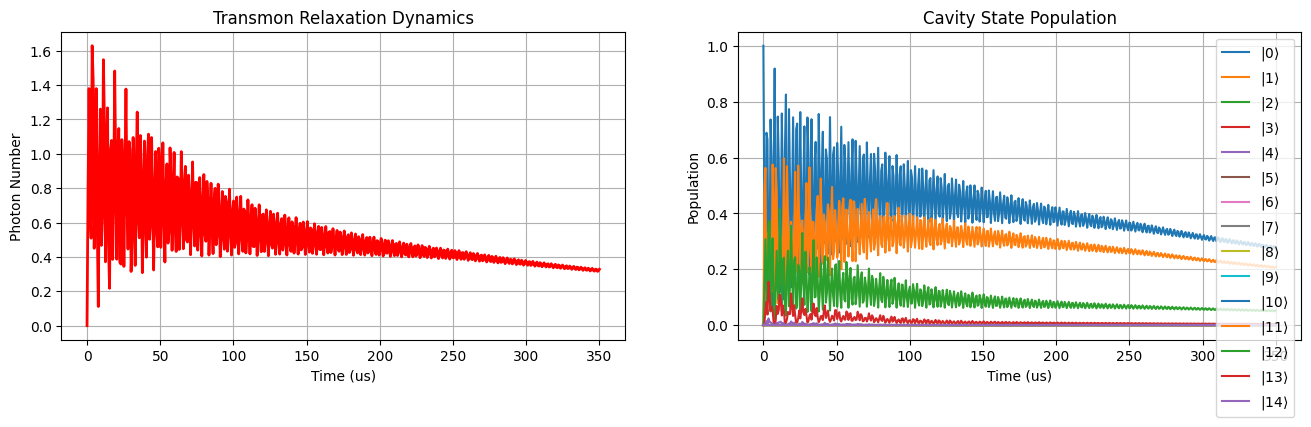

[ 2.7317825e-01  2.0930699e-01  5.3112827e-02  5.1083029e-03
 -3.7355849e-04 -1.9087947e-04 -2.0025189e-05  5.2528509e-07
  2.5366299e-07 -1.1980538e-08 -1.1872574e-08 -1.8294738e-09
 -1.5361673e-10 -1.1529822e-11 -8.2511721e-13]


In [53]:
# Analyzing the Results :
states_array = [rho.to_jax() for rho in result.states]
Populattion_cavity = jnp.array([jnp.diag(rho).real for rho in states_array])

fig, ax = plt.subplots(1, 2, figsize=(16,4))
ax[0].plot(times, result.expects[0].real, linewidth=2, color = "r")
ax[0].set_xlabel("Time (us)")
ax[0].set_ylabel("Photon Number")
ax[0].set_title("Transmon Relaxation Dynamics")
ax[0].grid()

for n in range(Nc):
    ax[1].plot(times, Populattion_cavity[:,n], label=rf"$\vert {n} \rangle$")
ax[1].set_xlabel("Time (us)")
ax[1].set_ylabel("Population")
ax[1].set_title("Cavity State Population")
ax[1].legend()
ax[1].grid()
plt.show()


#A = result.expects[0].real
#B = abs(params["drive_amplitude"]/(params["Delta_c"] + params["Kappa_c"]*1j/2))
#print(A[-1], B**2)
print(Populattion_cavity[-1].real)